In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interactive, FloatSlider
from IPython.display import display

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

In [10]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 784), 
            nn.ReLU(),
            nn.Linear(784, 256), 
            nn.ReLU(),
            nn.Linear(256, 128), 
            nn.ReLU(),
            nn.Linear(128, 64), 
            nn.ReLU(),
            nn.Linear(64, 2)
        )
        self.decoder = nn.Sequential(
            nn.Linear(2, 64), 
            nn.ReLU(),
            nn.Linear(64, 128), 
            nn.ReLU(),
            nn.Linear(128, 256), 
            nn.ReLU(),
            nn.Linear(256, 28 * 28), 
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        z = self.encoder(x)
        out = self.decoder(z)
        return out.view(-1, 1, 28, 28), z

def train_model(model, train_loader, test_loader, criterion, optimizer, epochs=10, scheduler=None):
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, _ in train_loader:
            images = images.to(device)

            optimizer.zero_grad()
            outputs, _ = model(images)
            loss = criterion(outputs, images)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images, _ in test_loader:
                images = images.to(device)
                outputs, _ = model(images)
                loss = criterion(outputs, images)
                val_loss += loss.item()

        val_loss = val_loss / len(test_loader)
        val_losses.append(val_loss)

        if scheduler is not None:
            scheduler.step(val_loss)

        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    return train_losses, val_losses

model_fc = Autoencoder().to(device)
criterion = nn.BCELoss()
optimizer_fc = optim.Adam(model_fc.parameters(), lr=1e-3)

fc_train_loss, fc_val_loss = train_model(model_fc, train_loader, test_loader, criterion, optimizer_fc, epochs=15)

Epoch [1/15] | Train Loss: 0.4083 | Val Loss: 0.3437
Epoch [2/15] | Train Loss: 0.3352 | Val Loss: 0.3323
Epoch [3/15] | Train Loss: 0.3296 | Val Loss: 0.3298
Epoch [4/15] | Train Loss: 0.3274 | Val Loss: 0.3278
Epoch [5/15] | Train Loss: 0.3255 | Val Loss: 0.3260
Epoch [6/15] | Train Loss: 0.3241 | Val Loss: 0.3254
Epoch [7/15] | Train Loss: 0.3228 | Val Loss: 0.3233
Epoch [8/15] | Train Loss: 0.3216 | Val Loss: 0.3234
Epoch [9/15] | Train Loss: 0.3214 | Val Loss: 0.3308
Epoch [10/15] | Train Loss: 0.3208 | Val Loss: 0.3218
Epoch [11/15] | Train Loss: 0.3203 | Val Loss: 0.3203
Epoch [12/15] | Train Loss: 0.3193 | Val Loss: 0.3204
Epoch [13/15] | Train Loss: 0.3201 | Val Loss: 0.3267
Epoch [14/15] | Train Loss: 0.3193 | Val Loss: 0.3210
Epoch [15/15] | Train Loss: 0.3186 | Val Loss: 0.3208


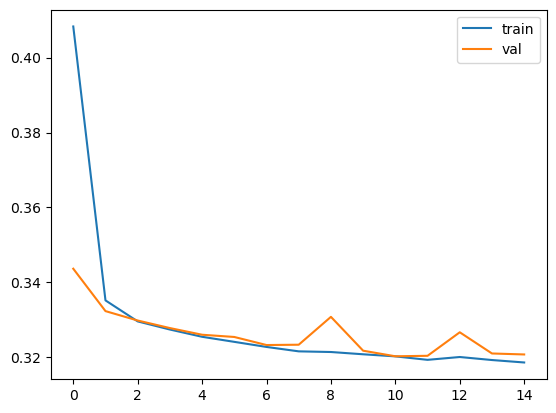

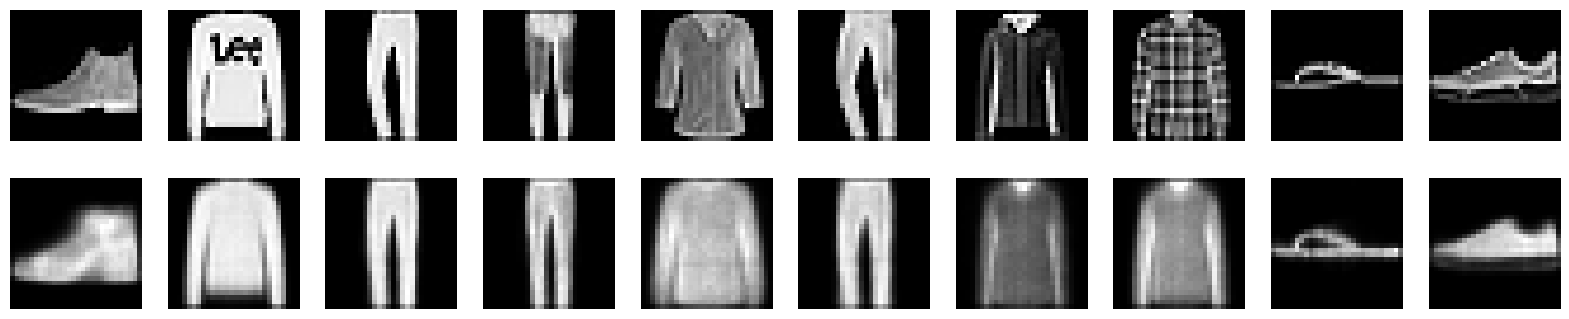

In [11]:
plt.plot(fc_train_loss, label='train')
plt.plot(fc_val_loss, label='val')
plt.legend()
plt.show()

def show_reconstructions(model, test_loader):
    model.eval()
    dataiter = iter(test_loader)
    images, _ = next(dataiter)
    images = images.to(device)

    with torch.no_grad():
        reconstructed, _ = model(images)

    images = images.cpu().numpy()
    reconstructed = reconstructed.cpu().numpy()

    plt.figure(figsize=(20, 4))
    for i in range(10):

        ax = plt.subplot(2, 10, i + 1)
        plt.imshow(images[i].squeeze(), cmap='gray')
        plt.axis("off")

        ax = plt.subplot(2, 10, i + 11)
        plt.imshow(reconstructed[i].squeeze(), cmap='gray')
        plt.axis("off")
    plt.show()

show_reconstructions(model_fc, test_loader)

In [12]:
class CNN_AE(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder
        self.enc_conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), 
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # стало 32 канала и 14х14

            nn.Conv2d(32, 16, kernel_size=3, padding=1), 
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.enc_fc = nn.Linear(16 * 7 * 7, 2) # делаем вектор 784 с сжатием до 2

        # Decoder
        self.dec_fc = nn.Sequential(nn.Linear(2, 16 * 7 * 7), 
                                    nn.ReLU())
        self.dec_conv = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(16, 16, kernel_size=3, padding=1), 
            nn.ReLU(),

            nn.Upsample(scale_factor=2, mode='nearest'), # получаем (16, 28, 28)
            nn.Conv2d(16, 1, kernel_size=3, padding=1), 
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.enc_conv(x)
        x = x.view(-1, 16 * 7 * 7)
        z = self.enc_fc(x)

        out = self.dec_fc(z)
        out = out.view(-1, 16, 7, 7)
        out = self.dec_conv(out)
        return out, z

model_cnn = CNN_AE().to(device)
optimizer_cnn = optim.Adam(model_cnn.parameters(), lr=1e-3)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer_cnn, mode='min', factor=0.5, patience=3, min_lr=1e-7)

cnn_train_loss, cnn_val_loss = train_model(model_cnn, train_loader, test_loader, criterion, optimizer_cnn, epochs=15, scheduler=scheduler)

Epoch [1/15] | Train Loss: 0.4635 | Val Loss: 0.3825
Epoch [2/15] | Train Loss: 0.3706 | Val Loss: 0.3658
Epoch [3/15] | Train Loss: 0.3609 | Val Loss: 0.3605
Epoch [4/15] | Train Loss: 0.3565 | Val Loss: 0.3578
Epoch [5/15] | Train Loss: 0.3539 | Val Loss: 0.3548
Epoch [6/15] | Train Loss: 0.3522 | Val Loss: 0.3531
Epoch [7/15] | Train Loss: 0.3507 | Val Loss: 0.3519
Epoch [8/15] | Train Loss: 0.3495 | Val Loss: 0.3506
Epoch [9/15] | Train Loss: 0.3485 | Val Loss: 0.3502
Epoch [10/15] | Train Loss: 0.3477 | Val Loss: 0.3491
Epoch [11/15] | Train Loss: 0.3470 | Val Loss: 0.3479
Epoch [12/15] | Train Loss: 0.3462 | Val Loss: 0.3478
Epoch [13/15] | Train Loss: 0.3457 | Val Loss: 0.3470
Epoch [14/15] | Train Loss: 0.3450 | Val Loss: 0.3461
Epoch [15/15] | Train Loss: 0.3446 | Val Loss: 0.3459


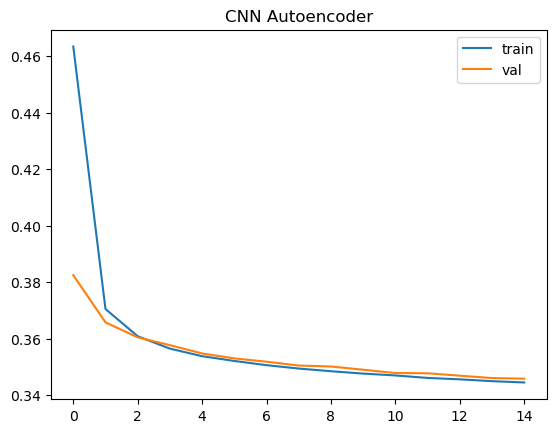

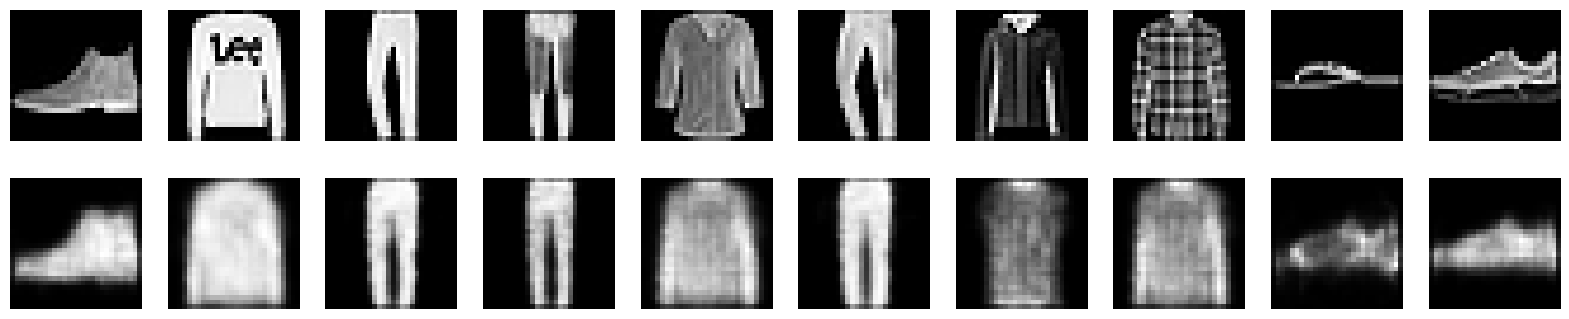

In [13]:
plt.plot(cnn_train_loss, label='train')
plt.plot(cnn_val_loss, label='val')
plt.title("CNN Autoencoder")
plt.legend()
plt.show()

show_reconstructions(model_cnn, test_loader)

In [ ]:
# Сбор данных для пределов ползунков
model_cnn.eval()
all_z = []
with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        _, z = model_cnn(images)
        all_z.append(z.cpu().numpy())

z_test = np.concatenate(all_z, axis=0)
z1_min, z1_max = float(z_test[:, 0].min()), float(z_test[:, 0].max())
z2_min, z2_max = float(z_test[:, 1].min()), float(z_test[:, 1].max())

def plot_latent(z1, z2):
    latent = torch.tensor([[z1, z2]], dtype=torch.float32).to(device)

    with torch.no_grad():
        out = model_cnn.dec_fc(latent)
        out = out.view(-1, 16, 7, 7)
        decoded = model_cnn.dec_conv(out).cpu().numpy()[0]

    plt.figure(figsize=(4, 4))
    plt.imshow(decoded.squeeze(), cmap='gray')
    plt.axis('off')
    plt.show()

interactive_plot = interactive(
    plot_latent,
    z1=FloatSlider(min=z1_min, max=z1_max, step=0.01, value=(z1_min + z1_max)/2, description='z1'),
    z2=FloatSlider(min=z2_min, max=z2_max, step=0.01, value=(z2_min + z2_max)/2, description='z2'))

display(interactive_plot)

interactive(children=(FloatSlider(value=7.991681754589081, description='z1', max=17.95830726623535, min=-1.974…